In [1]:
import numpy as np
import matplotlib.pyplot as plt
from generate_basic_mask import DetectorMaskGenerator

In [2]:
%matplotlib widget

In [3]:
tiff_fn = 'test_data/Cs_000_Br_100_Pb_100_OLA_020_PF_018_Tol_1100_20250607-195546_91db25_scattering-dk_sub_image-00000.tiff'
mask_fn = 'test_data/Mask_Cs_000_Br_100_Pb_100_OLA_020_PF_018_Tol_1100_20250607-195546_91db25.npy'

In [4]:
gen = DetectorMaskGenerator(
    tiff_fn,
    baseline_mask_npy=mask_fn,  # optional
    use_median_filter=True, 
    frame = 0, 
    median_window = 7, 
    median_tile_rows = 256, 
    zscore_window = 7,
    zscore_tile_rows = 256, 
    log_low_percentile = 5.0,
    log_high_percentile = 100.0,
    dead_z = -8.0,
    hot_z = 20.0,
    sigma_floor_percentile = 5,
    beamstop = "off",
    # beamstop_low_percentile = 3.0,
    # beamstop_search_half_width = 120,
    # beamstop_max_anchor_distance = 50,
    # beamstop_min_run_width = 3,
    # beamstop_max_run_width = 80,
    # beamstop_padding = 8,
    # beamstop_tip_radius_x = 24,
    # beamstop_tip_radius_y = 32,
    use_radial_detector=True,
    center_x=1056.9359215924487,
    center_y=1033.5235675591755,
    radial_sigma_floor_percentile=5.0, 
    radial_profile_exclude_masked=False, 
    radial_bin_width=0.5,
    radial_min_bin_pixels=10, 
    radial_hot_z=3.5,
    radial_component_min_pixels=1, 
    radial_component_max_pixels=400,
    radial_component_max_width=20,
    radial_component_max_height=20, 
    radial_component_max_aspect_ratio=5,
    border = 15,
    dilate = 0, 
)

mask = gen.generate_mask()
gen.save_mask_npy("test_data/output_mask_Cs_000_Br_100_Pb_100_OLA_020_PF_018_Tol_1100_20250607-195546_91db25")

PosixPath('/nsls2/users/clin1/Documents/Git_BNL/auto_ADmask/test_data/output_mask_Cs_000_Br_100_Pb_100_OLA_020_PF_018_Tol_1100_20250607-195546_91db25')

In [5]:
# params

In [6]:
plt.close('all')

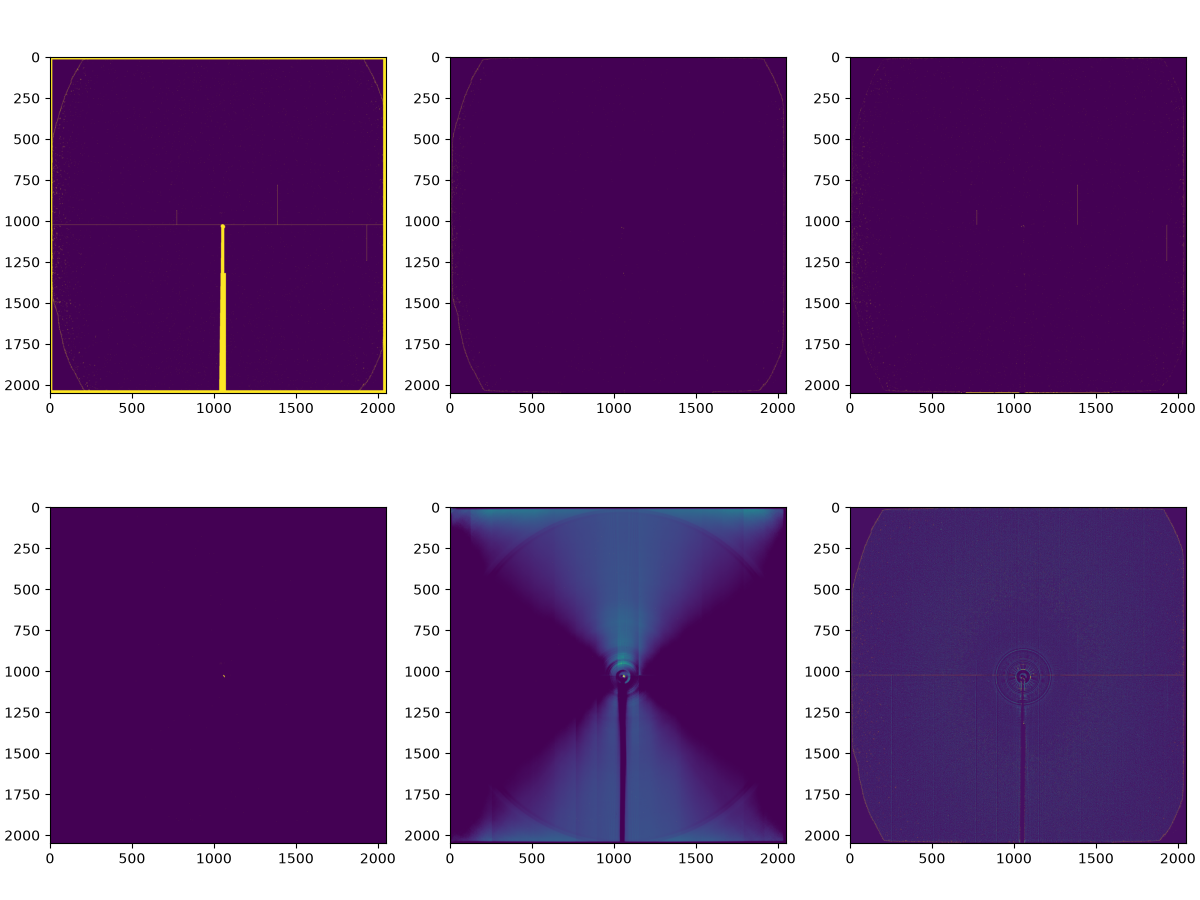

In [7]:
f1, ax1 = plt.subplots(2, 3, figsize = (12, 9), constrained_layout=True)
ax1[0,0].imshow(mask)
ax1[0,1].imshow(gen.hot_mask)
ax1[0,2].imshow(gen.dead_mask)
ax1[1,0].imshow(gen.radial_mask)
ax1[1,1].imshow(gen.radial_zscore, vmin=-0.2, vmax=4.5)
ax1[1,2].imshow(gen.local_zscore, vmin=-0.2, vmax=4.5)

plt.show()

In [ ]:
gen.parameters

In [ ]:
float(params["hot_z"])

In [ ]:
hot_mask = gen.finite & (gen.local_zscore >= 50)

In [ ]:
plt.figure()
plt.imshow(hot_mask)
plt.show()

In [ ]:
gen._merged_parameters({'window':101})

In [ ]:
t = gen.median_filter_tiled(gen.raw, 3, 2)

In [ ]:
plt.figure()
plt.imshow(t)
plt.show()